In [2]:
# =========================================================
# 1. PROJECT TITLE / BUSINESS FRAMING
# =========================================================

"""
Project: Optimizing Detection Time in Distributed Search Systems

Goal:
Analyze how increasing the number of independent searchers changes the Initial First Contact Time (IFCT) to a target, and identify
when scaling searchers give diminishing returns.

Why it matters:
This problem maps to real-world distributed systems such as:
- anomaly/fraud detection
- distributed monitoring
- network search
- resource allocation problems

Main questions:
1. How does IFCT change as the number of searchers N increases?
2. Does IFCT follow 1/N, 1/log(N), or both in different regimes?
3. How does search-space size affect the transition point?
"""

'\nProject: Optimizing Detection Time in Distributed Search Systems\n\nGoal:\nAnalyze how increasing the number of independent searchers changes the Initial First Contact Time (IFCT) to a target, and identify\nwhen scaling searchers give diminishing returns.\n\nWhy it matters:\nThis problem maps to real-world distributed systems such as:\n- anomaly/fraud detection\n- distributed monitoring\n- network search\n- resource allocation problems\n\nMain questions:\n1. How does IFCT change as the number of searchers N increases?\n2. Does IFCT follow 1/N, 1/log(N), or both in different regimes?\n3. How does search-space size affect the transition point?\n'

In [3]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats.distributions import  t
import matplotlib.pyplot as plt

In [4]:
def load_dataset(file_path, walk_type, metric, dc_scaling, mass_values, searchers, targets, predicted_exponent):
    df = pd.read_csv(file_path, sep="\t", header=None)
    df.columns = mass_values
    df = df.melt(var_name="mass", value_name="value")

    mass_to_searchers = dict(zip(mass_values,searchers))
    mass_to_targets = dict(zip(mass_values, targets))

    df["searchers"] = df["mass"].map(mass_to_searchers)
    df["targets"] = df["mass"].map(mass_to_targets)
    df["walk_type"] = walk_type
    df["metric"] = metric
    df["dc_scaling"] = dc_scaling
    df["predicted_exponent"] = predicted_exponent
    df["source"] = "Raw"
    print(df)
    return df

In [5]:
Number_of_cases = 6

In [6]:
# Arranging X data
mass = np.arange(1, Number_of_cases, 1)
mass_values = np.power(10, mass)

In [7]:
# Number of Searchers
searchers = [20] #In a mouse (10gm) sized lymph node, there are around 20 T cells specific to a particular antigen
for i in range(1,Number_of_cases-1):
    searchers.append(round((searchers[i-1] * mass_values[i] ** 0.5) /mass_values[i-1]**0.5))
searchers[:5]

[20, 63, 199, 629, 1989]

In [8]:
# Number of Targets
targets_half = [80] #In a mouse (10gm) sized lymph node, there are around 80 Dendritic Cells specific to a particular antigen
targets_constant = [200]
for i in range(1,Number_of_cases-1):
    targets_half.append(np.ceil((targets_half[i-1] * mass_values[i] ** 0.5) /mass_values[i-1]**0.5)) #targets[i] ~ mass_values[i]^0.5
    targets_constant.append(targets_constant[i-1])
targets_constant

[200, 200, 200, 200, 200]

In [9]:

df_all = pd.concat([
    load_dataset("./Data/CRW_IFCT_DCHalf.csv", "CRW", "IFCT", "Half", mass_values, searchers, targets_half, predicted_exponent=-0.5),
    load_dataset("./Data/CRW_IFCT_DCConstant.csv", "CRW", "IFCT", "Constant", mass_values, searchers, targets_constant, predicted_exponent=0),
    load_dataset("./Data/CRW_MFCT_DCHalf.csv", "CRW", "MFCT", "Half", mass_values, searchers, targets_half, predicted_exponent=0),
    load_dataset("./Data/CRW_MFCT_DCConstant.csv", "CRW", "MFCT", "Constant", mass_values, searchers, targets_constant, predicted_exponent=0.5),

    load_dataset("./Data/BM_IFCT_DCHalf.csv", "BM", "IFCT", "Half", mass_values, searchers, targets_half, predicted_exponent=-0.5),
    load_dataset("./Data/BM_IFCT_DCConstant.csv", "BM", "IFCT", "Constant", mass_values, searchers, targets_constant, predicted_exponent=0.0),
    load_dataset("./Data/BM_MFCT_DCHalf.csv", "BM", "MFCT", "Half", mass_values, searchers, targets_half, predicted_exponent=0.0),
    load_dataset("./Data/BM_MFCT_DCConstant.csv", "BM", "MFCT", "Constant", mass_values, searchers, targets_constant, predicted_exponent=0.5),
], ignore_index=True)

       mass  value  searchers  targets walk_type metric dc_scaling  \
0        10    487         20     80.0       CRW   IFCT       Half   
1        10   1914         20     80.0       CRW   IFCT       Half   
2        10   4287         20     80.0       CRW   IFCT       Half   
3        10    459         20     80.0       CRW   IFCT       Half   
4        10   6634         20     80.0       CRW   IFCT       Half   
..      ...    ...        ...      ...       ...    ...        ...   
495  100000     15       1989   8011.0       CRW   IFCT       Half   
496  100000     13       1989   8011.0       CRW   IFCT       Half   
497  100000      3       1989   8011.0       CRW   IFCT       Half   
498  100000     85       1989   8011.0       CRW   IFCT       Half   
499  100000     19       1989   8011.0       CRW   IFCT       Half   

     predicted_exponent source  
0                  -0.5    Raw  
1                  -0.5    Raw  
2                  -0.5    Raw  
3                  -0.5    

In [10]:
def arrangeXdata(n, x):
    n_per_mass = n  # number of simulation per mass
    mAllP = np.repeat(x, n_per_mass)  # length 5*20 = 100 #used to fit the data
    M = np.linspace(min(x), max(x), num=100, endpoint=True) #used to plot the data
    return mAllP, M
filtered = df_all[(df_all['mass'] == 10) & (df_all["walk_type"]=="BM") & (df_all["metric"]=="IFCT") & (df_all["dc_scaling"] == "Constant")]
mAllP, M = arrangeXdata(len(filtered), mass_values)

In [11]:
df_all = df_all.dropna()
df_all["mass"] = df_all["mass"].astype(float)
df_all["value"] = df_all["value"].astype(float)
df_all.head()

,mass,value,searchers,targets,walk_type,metric,dc_scaling,predicted_exponent,source
0,10.0,487.0,20,80.0,CRW,IFCT,Half,-0.5,Raw
1,10.0,1914.0,20,80.0,CRW,IFCT,Half,-0.5,Raw
2,10.0,4287.0,20,80.0,CRW,IFCT,Half,-0.5,Raw
3,10.0,459.0,20,80.0,CRW,IFCT,Half,-0.5,Raw
4,10.0,6634.0,20,80.0,CRW,IFCT,Half,-0.5,Raw


In [12]:
filtered = df_all[(df_all["walk_type"]=="CRW")]

grouped = (
    filtered.groupby(["mass", "metric", "dc_scaling"])["value"]
    .mean()
    .reset_index()
)

print(grouped.head())


    mass metric dc_scaling       value
0   10.0   IFCT   Constant   1098.1400
1   10.0   IFCT       Half   2737.3500
2   10.0   MFCT   Constant  20210.2305
3   10.0   MFCT       Half  53172.8735
4  100.0   IFCT   Constant   1896.2800


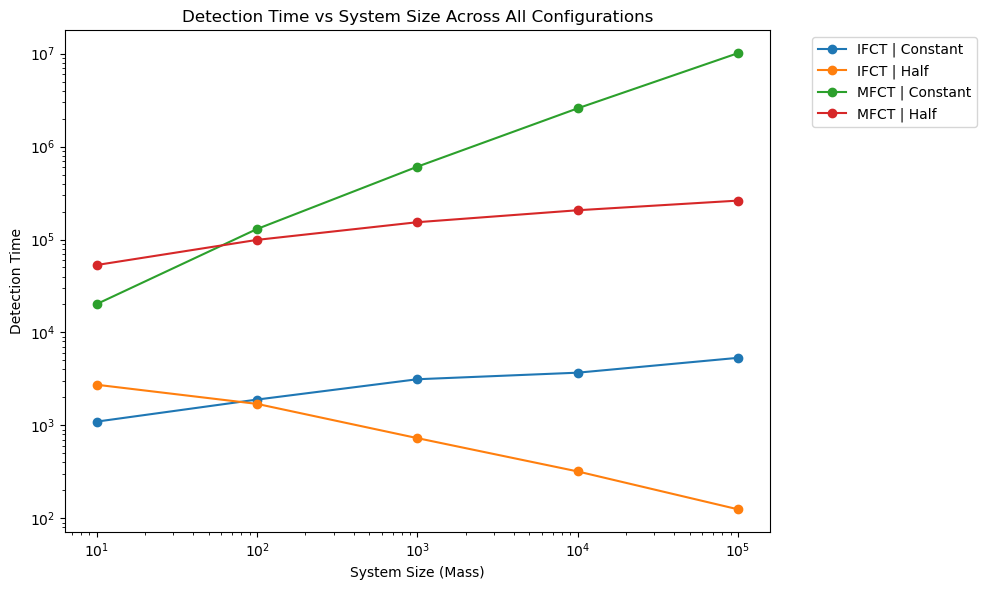

In [13]:
# Overall comparison of all configurations
plt.figure(figsize=(10, 6))
for key, subdf in grouped.groupby([ "metric", "dc_scaling"]):
    label = f"{key[0]} | {key[1]}"
    plt.plot(np.array(subdf["mass"]), np.array(subdf["value"]), marker="o", label=label)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("System Size (Mass)")
plt.ylabel("Detection Time")
plt.title("Detection Time vs System Size Across All Configurations")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [14]:
# n1*M^n2*log(n3M)
def objective(x, n1, n2, n3):
    return n1 + n2*x + np.log10(n3 + (x*np.log(10)))


In [15]:

def predict_time(body_mass, popt, pred_exp):   
    logM = np.log10(body_mass)
    n1,n2, n3 = popt
    logy = objective(logM, n1, n2, n3)
    logy_pred = objective(logM, n1, pred_exp, n3)
    return (10 ** logy) / 60.0, (10 ** logy_pred) / 60.0  # in minutes


In [16]:
#Finding errorBar
def errorBar(data_log):
    stderror= np.std(data_log) / np.sqrt( len( data_log))
    er_Upper = np.mean(data_log) + 1.96 * stderror
    er_Lower = np.mean(data_log) - 1.96 * stderror
    return er_Upper, er_Lower

In [20]:
# curve fit for mean, DC ~ constant
def curve_fit_objective(x, Y_all, PredictedExponent, wORwoLog): #wORwoLog = "wLog" (with Log) or "woLog" (without Log) 
    
    valid = ~(np.isnan(x) | np.isnan(Y_all))
    params, covar = curve_fit(objective, x, Y_all[valid], bounds=((-np.Inf, -np.Inf, 0),(np.Inf, np.Inf, np.Inf)))
    
    # summarize the parameter values
    n = len(Y_all)    # number of data points
    alpha = 0.05 # 95% confidence interval = 100*(1-alpha)
    p = len(params) # number of parameters
    dof = max(0, n - p) # number of degrees of freedom
    
    # student-t value for the dof and confidence level
    tval = t.ppf(1.0-alpha/2., dof) 
    var = np.diag(covar)
    sigma = var[0]**0.5
    n1_CI = sigma*tval
    sigma = var[1]**0.5
    n2_CI = sigma*tval
    sigma = var[2]**0.5
    n3_CI = sigma*tval

    n1, n2, n3 = params
    y_fit = objective(x,*params)
    # calculate the output for the range M
    M = np.linspace(x.min(), x.max(), 100)
    y_fit_line = objective(M, *params)
    y_Upper_line = objective(M, n1 + n1_CI, n2 + n2_CI, n3 + n3_CI)
    y_Lower_line = objective(M, n1 - n1_CI, n2 - n2_CI, n3 - n3_CI)
    y_pred_line = n1 + PredictedExponent * M + np.log10((n3) + (M*np.log(10)))
    print('y = %.2f * M^{%0.2f +/- %0.2f} * log( %.2f * M)' % (n1, n2,n2_CI,n3))
        

    mice_fit,   mice_pred   = predict_time(24, params, PredictedExponent)
    kg1_fit,    kg1_pred    = predict_time(1000, params, PredictedExponent)
    human_fit,  human_pred  = predict_time(62000, params, PredictedExponent)

    print(f'mice (24 g): fit = {mice_fit:.3f} min, predicted = {mice_pred:.3f} min')
    print(f'1 kg:        fit = {kg1_fit:.3f} min, predicted = {kg1_pred:.3f} min')
    print(f'human 62 kg: fit = {human_fit:.3f} min, predicted = {human_pred:.3f} min\n')

       
    return y_fit, y_fit_line, y_Upper_line, y_Lower_line, y_pred_line, params, M

In [43]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def aic(y_true, y_pred, k):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    return n * np.log(rss / n) + 2 * k

def bic(y_true, y_pred, k):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    return n * np.log(rss / n) + k * np.log(n)

In [49]:
results = []
curve_points = [] 
filtered = df_all[(df_all["walk_type"]=="CRW")]
for key, subdf in filtered.groupby([ "walk_type","metric", "dc_scaling", "predicted_exponent"]):
    walk_type, metric, dc_scaling, pred_exp = key
    x = np.log10(subdf["mass"].values)
    y = np.log10(subdf["value"].values)
    exp_val = subdf["predicted_exponent"].iloc[0]
    y_fit, y_fit_line, y_Upper_line, y_Lower_line, y_pred_line, params, M = curve_fit_objective(x, y, exp_val, "wLog")
    
    er_UpperMC, er_LowerMC = errorBar(np.log10(subdf['value']))

    k = len(params)


    median_df = np.log10(subdf.groupby("mass", as_index=False)["value"].median().rename(columns={"value": "median_value"}))

    median_df["median_fit"] = objective(median_df["mass"], *params)
    results.append({
        "walk_type": key[0],
        "metric": key[1],
        "dc_scaling": key[2],
        "Predicted_exponent": key[3],
        "a": round(params[0],2),
        "exponent": round(params[1],2),
        "rmse_med": 10**rmse(median_df["median_value"], median_df["median_fit"]),
        "r2": r_squared(median_df["median_value"], median_df["median_fit"]),
        "aic": aic(median_df["median_value"], median_df["median_fit"], k),
        "bic": bic(median_df["median_value"], median_df["median_fit"], k),
        "r2": r_squared(median_df["median_value"], median_df["median_fit"]),
        "aic": aic(median_df["median_value"], median_df["median_fit"], k),
        "bic": bic(median_df["median_value"], median_df["median_fit"], k),
        "n_obs": len(median_df["median_value"])
    })

    for i in range(len(M)):
            curve_points.append({
                "walk_type": walk_type,
                "metric": metric,
                "dc_scaling": dc_scaling,
                "predicted_exponent": pred_exp,
                "mass": 10**M[i],
                "value": 10**y_fit_line[i],
                "upper": 10**y_Upper_line[i],
                "lower": 10**y_Lower_line[i],
                "predicted_value": 10**y_pred_line[i],
                "source" :"fit"
                
            })
        
        

df_results = pd.DataFrame(results)
df_curves = pd.DataFrame(curve_points)
print(df_results)

y = 2.13 * M^{0.04 +/- 0.10} * log( 2.21 * M)
mice (24 g): fit = 14.081 min, predicted = 12.235 min
1 kg:        fit = 28.102 min, predicted = 20.704 min
human 62 kg: fit = 48.996 min, predicted = 30.077 min

y = 3.13 * M^{-0.48 +/- 0.10} * log( 1.42 * M)
mice (24 g): fit = 22.360 min, predicted = 20.974 min
1 kg:        fit = 6.764 min, predicted = 5.886 min
human 62 kg: fit = 1.396 min, predicted = 1.118 min

y = 3.44 * M^{0.50 +/- 0.01} * log( 0.00 * M)
mice (24 g): fit = 712.276 min, predicted = 706.523 min
1 kg:        fit = 10089.091 min, predicted = 9912.795 min
human 62 kg: fit = 128248.727 min, predicted = 124687.534 min

y = 4.28 * M^{0.01 +/- 0.01} * log( 0.31 * M)
mice (24 g): fit = 1158.325 min, predicted = 1111.551 min
1 kg:        fit = 2514.803 min, predicted = 2299.296 min
human 62 kg: fit = 4169.621 min, predicted = 3613.606 min

  walk_type metric dc_scaling  Predicted_exponent     a  exponent  rmse_med  \
0       CRW   IFCT   Constant                 0.0  2.13      

/tmp/ipykernel_7732/1668341300.py:3: RuntimeWarning: invalid value encountered in log10
  return n1 + n2*x + np.log10(n3 + (x*np.log(10)))
/tmp/ipykernel_7732/1668341300.py:3: RuntimeWarning: invalid value encountered in log10
  return n1 + n2*x + np.log10(n3 + (x*np.log(10)))


In [23]:
df_raw = df_all.copy()

df_raw["fitted_values"] = np.nan
df_raw["upper"] = np.nan
df_raw["lower"] = np.nan
df_raw["predicted_value"] = np.nan

df_all_combined = pd.concat([
    df_raw[["mass", "value", "walk_type", "metric", "dc_scaling", "source"]],
    df_curves[["mass", "value", "upper", "lower", "predicted_value", "walk_type", "source"]]
])
df_all_combined.to_csv("combined_for_tableau.csv", index=False)
df_all_combined.head()
check = df_all_combined[np.isnan(df_all_combined["predicted_value"])==False]

In [ ]:
df_results.to_csv("model_parameters.csv", index=False)
df_curves.to_csv("fitted_curves.csv", index=False)
df_all["value"] = pd.to_numeric(df_all["value"], errors="coerce")
df_all.to_csv("simulated_data.csv", index=False, sep=",")

In [ ]:
df_results.head()

In [ ]:
df_curves.head()

In [ ]:
#DEMO

filtered = df_all[
    (df_all["walk_type"] == "BM") &
    (df_all["metric"] == "IFCT") &
    (df_all["dc_scaling"] == "Constant")
].copy()

x = np.log10(filtered["mass"].values)
y = np.log10(filtered["value"].values)

params, covar = curve_fit(
    objective,
    x,
    y,
    bounds=((-np.inf, -np.inf, 0), (np.inf, np.inf, np.inf))
)

M = np.linspace(x.min(), x.max(), 100)
y_pred = objective(M, *params)

plt.figure()
plt.scatter(x, y, alpha=0.4, label="All replicate values")
plt.plot(M, y_pred, label="Fitted curve")

plt.xlabel("log10(Mass)")
plt.ylabel("log10(Contact Time)")
plt.title("Fit using all replicate values")
plt.legend()
plt.show()

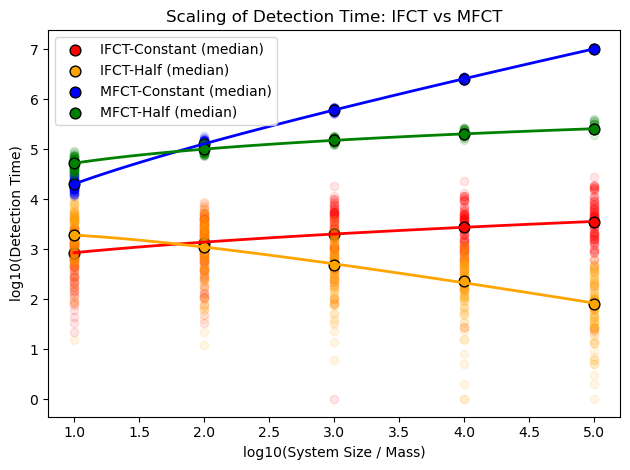

In [50]:
colors = {
    ("CRW", "IFCT", "Constant"): "red",
    ("CRW", "IFCT", "Half"): "orange",
    ("CRW", "MFCT", "Constant"): "blue",
    ("CRW", "MFCT", "Half"): "green",
}

for (walk_type, metric, dc_scaling), subdf in df_all.groupby(
    ["walk_type", "metric", "dc_scaling"]
):
    if walk_type != "CRW":
        continue  # keep clean for one figure
    
    # Prepare data
    subdf = subdf.copy()
    subdf["log_mass"] = np.log10(subdf["mass"])
    subdf["log_value"] = np.log10(subdf["value"])
    
    # Plot faint replicate points
    plt.scatter(
        subdf["log_mass"],
        subdf["log_value"],
        alpha=0.1,
        color=colors[(walk_type, metric, dc_scaling)]
    )
    
    # Compute median per mass
    median_df = (
        subdf.groupby("mass", as_index=False)["value"]
        .median()
        .rename(columns={"value": "median_value"})
    )
    
    median_df["log_mass"] = np.log10(median_df["mass"])
    median_df["log_median"] = np.log10(median_df["median_value"])
    
    # Fit model on medians
    popt, _ = curve_fit(
        objective,
        median_df["log_mass"],
        median_df["log_median"],
        bounds=((-np.inf, -np.inf, 0), (np.inf, np.inf, np.inf))
    )
    
    # Smooth curve
    M = np.linspace(median_df["log_mass"].min(), median_df["log_mass"].max(), 100)
    y_fit = objective(M, *popt)
    
    # Plot median points
    plt.scatter(
        median_df["log_mass"],
        median_df["log_median"],
        s=60,
        edgecolor="black",
        color=colors[(walk_type, metric, dc_scaling)],
        label=f"{metric}-{dc_scaling} (median)"
    )
    
    # Plot fitted curve
    plt.plot(
        M,
        y_fit,
        linewidth=2,
        color=colors[(walk_type, metric, dc_scaling)]
    )

plt.xlabel("log10(System Size / Mass)")
plt.ylabel("log10(Detection Time)")
plt.title("Scaling of Detection Time: IFCT vs MFCT")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# #For Paper
# #Mean and Initial First Contact time (Merged)
# linestyle_str = [
#      ('solid', 'solid'),      # Same as (0, ()) or '-'
#      ('dotted', 'dotted'),    # Same as (0, (1, 1)) or ':'
#      ('dashed', 'dashed'),    # Same as '--'
#      ('dashdot', 'dashdot')]  # Same as '-.'

# linestyle_tuple = [
#      ('loosely dotted',        (0, (1, 10))),
#      ('dotted',                (0, (1, 1))),
#      ('densely dotted',        (0, (1, 1))),

#      ('loosely dashed',        (0, (5, 10))),
#      ('dashed',                (0, (5, 5))),
#      ('densely dashed',        (0, (5, 1))),

#      ('loosely dashdotted',    (0, (3, 10, 1, 10))),
#      ('dashdotted',            (0, (3, 5, 1, 5))),
#      ('densely dashdotted',    (0, (3, 1, 1, 1))),

#      ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
#      ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
#      ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]


# fontsize = 30
# fig, axes = plt.subplots(1, 2, figsize=(18, 8.27), constrained_layout=True)
# axes0, axes1 = axes.flatten()


# (row, col) = np.shape(data_logMH)
# for i in range(0,col):
#     temp = []
#     for j in range(0,row):
#         temp.append(mass[i])
    
#     axes0.scatter(np.log10(temp), np.log10(dataMH[i]), facecolors='none', edgecolors = "blue")
#     axes0.scatter(np.log10(temp), np.log10(dataFH[i]), facecolors='none', edgecolors = "red")
#     axes1.scatter(np.log10(temp), np.log10(dataMC[i]), facecolors='none', edgecolors = "blue")
#     axes1.scatter(np.log10(temp), np.log10(dataFC[i]), facecolors='none', edgecolors = "red")
    
# # create a line plot for the mapping function and Perelson's prediction
# #lb = r'ABM: Expected first contact time $\propto M^{%0.2lf \pm %0.2lf}\ln(cM)$'%(n2_MC,n2_CI_MC)
# #lb = rf"Simulated: $\bar \tau \propto M^{{{n2_MC:.2f}\pm{n2_CI_MC:.2f}}}\ln(cM)$"
# lb = rf"Simulated: $\bar \tau$"
# axes1.plot(M, y_MC, label=lb, linewidth=6, color = "lightblue", linestyle="solid")
# #lb = r'Theory: Expected first contact time $\propto M^{0.5}\ln(cM)$'
# #lb = rf'Predicted: $\bar \tau \propto M^{{0.5}}\ln(cM)$'
# lb = rf'Predicted: $\bar \tau$'
# axes1.plot(M, y_PerelsonMC, label=lb, linestyle=(0,(2,3)), linewidth=4, color = "dodgerblue")
# #lb = r'Simulation: Initial first contact time $\propto M^{%0.2lf \pm %0.2lf}\ln(cM)$'%(n2_FC,n2_CI_FC)
# #lb = rf"Simulated: $\tau_{{init}} \propto M^{{{n2_FC:.2f}\pm{n2_CI_FC:.2f}}}\ln(cM)$"
# lb = rf"Simulated: $\tau_{{init}}$"
# axes1.plot(M, y_FC, label=lb, linewidth=6, color = "lightcoral", linestyle="solid")

# #lb = rf"Predicted: $\tau_{{init}} \propto M^{{0}}\ln(cM)$"
# lb = rf"Predicted: $\tau_{{init}}$"
# axes1.plot(M, y_PerelsonFC, label=lb, linestyle=(0,(5,1)), linewidth=4, color = "maroon")
# #axes[0].set_xlabel(r"Mass: M g", fontsize=18)
# #axes[0].legend(shadow=False, fancybox=False, loc='upper left', prop={'size': 20})


# # plot input vs output Mean and first contact order, DC constant
# # create a line plot for the mapping function and Perelson's prediction
# #lb = rf"Simulated: $\bar \tau \propto M^{{{n2_MH:.2f}\pm{n2_CI_MH:.2f}}}\ln(cM)$"
# lb = rf"Simulated: $\bar \tau$"
# axes0.plot(M, y_MH, label=lb, linewidth=6, color = "lightblue", linestyle="solid")
# diff = y_MH[0] - y_PerelsonMH[0]

# #lb = rf'Predicted: $\bar \tau \propto M^{0}\ln(cM)$'
# lb = rf'Predicted: $\bar \tau$'
# axes0.plot(M, y_PerelsonMH+diff, label=lb, linestyle=(0,(3,2)), linewidth=4, color = "dodgerblue")

# #lb = rf"Simulated: $\tau_{{init}} \propto M^{{{n2_FH:.2f}\pm{n2_CI_FH:.2f}}}\ln(cM)$"
# lb = rf"Simulated: $\tau_{{init}}$"
# axes0.plot(M, y_FH, label=lb, linewidth=6, color = "lightcoral", linestyle="solid")

# #lb = rf'Predicted: $\tau_{{init}} \propto M^{{-0.5}}\ln(cM)$'
# lb = rf'Predicted: $\tau_{{init}}$'
# axes0.plot(M, y_PerelsonFH, label=lb, linestyle=(0,(5,1)), linewidth=4, color = "maroon")

# for ax in axes.flatten():
#     ax.label_outer()  # hides x labels on top row and y labels on right column

# # global (common) axis labels
# # fig.supxlabel('Mass (g)', fontsize=fontsize, fontweight='bold')

# # optionally adjust tick formatting to reflect powers of ten only on visible axes
# y_max = 12
# x_ticks = np.arange(0, 8)
# y_ticks = np.arange(0, y_max)
# ticks = [rf'$10^{{{i}}}$' for i in range(0, y_max)]
# for i in range(0,y_max,2):
#     ticks[i] = ''


# title_label = [f"(A): Systemic infection", f"(B): Localized infection"] 
# for i, ax in enumerate([axes0, axes1]):  # bottom row will show x; left column shows y
#     ax.set_xticks(x_ticks)
#     ax.set_yticks(y_ticks)
#     ax.set_xticklabels([rf'$10^{{{i}}}$' for i in x_ticks], fontsize=fontsize)
#     ax.set_yticklabels(ticks, fontsize=fontsize)
#     ax.legend(prop={'size':22})
#     #ax.set_title(title_label[i], fontsize=fontsize, weight = 'bold', loc="left")
#     #ax.legend(shadow=False, frameon=False, fancybox=False, loc='upper left', prop={'family':fontname,'size': fontsize})
# axes0.set_xlim([0.75, 5.25])
# axes1.set_xlim([0.75, 5.25])

# # If you want a model Figure, call Putting an Image with the subplot as follow:
# # puttingAnImage(axes0)

# def tick_function(X):
#     V = np.ceil(np.power(np.power(10,X),0.5)*np.log(np.power(10,X)))
#     return ["%.f" % z for z in V]
# new_tick_locations = x_ticks

# ax1 = axes0.twiny()
# ax2 = axes1.twiny()

# ax1.set_xlim(axes0.get_xlim())
# ax1.set_xticks(x_ticks)
# ax1.set_xticklabels(tick_function(x_ticks), fontsize=20, fontname = "Times New Roman")
# #ax1.set_xlabel(r"$V_{LN}$ (mm$^3)$", fontsize=22, fontname = "Times New Roman")
# #ax1.set_yticklabels(yAxis, fontsize=22, fontname = "Times New Roman")

# ax2.set_xlim(axes1.get_xlim())
# ax2.set_xticks(new_tick_locations)
# ax2.set_xticklabels(tick_function(new_tick_locations), fontsize=20, fontname = "Times New Roman")
# #ax2.set_xlabel(r"$V_{LN}$ (mm$^3)$", fontsize=22, fontname = "Times New Roman")
# #ax2.set_yticklabels(yAxis, fontsize=22, fontname = "Times New Roman")
# ax1.set_xlim([0.75, 5.25])
# ax2.set_xlim([0.75, 5.25])

# title_y_position = 1.15  # adjust height as needed (above V_LN at 1.03–1.05)

# fig.text(0.55, -0.05, 'Mass (g)', ha='center', fontsize=fontsize, weight = 'bold')
# fig.text(0.55, 1.05, r'$\mathbf{V_{LN}}\ \mathbf{(mm^3)}$', ha='center', fontsize=fontsize, weight = 'bold')
# fig.text(0.15, title_y_position, title_label[0], fontsize=fontsize, fontweight='bold', ha='left')
# fig.text(0.65, title_y_position, title_label[1], fontsize=fontsize, fontweight='bold', ha='left')
# fig.supylabel('Time (s)', fontsize=fontsize, fontweight='bold')


# # simulation_handle = Line2D([0], [0], color='black', marker='o', markersize=14, lw=6, label='Simulation')
# # predicted_handle = Line2D([0], [0], color='black', lw=6, alpha=0.3, label='Prediction')
# # Add custom legend to the axes



# plt.savefig('IFCT_MFCT.eps', format='eps', bbox_inches='tight')
# plt.savefig('IFCT_MFCT.png', format='png', bbox_inches='tight')
# plt.savefig('IFCT_MFCT.svg', format='svg', bbox_inches='tight')
# plt.savefig('IFCT_MFCT.pdf', format='pdf', bbox_inches='tight')
# plt.show()